# 0. import and inputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# define the folder directory
albedo_testing_folder = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\SunSolve Yield\Per inverter\2-1\25_11_27_linear_albedo_interpolation_hypothesis_testing"

# 1. Data loading

In [2]:
import os

# define a list to collect the df
df_list = []

# define a list to collect the albedo values
albedo_list = []

# for each files in the alebdo_testing_folder
for file in os.listdir(albedo_testing_folder):
    print('examining the file ', file)
    # if the file is a csv file
    if file.endswith('.csv'):
        # read the csv file
        df = pd.read_csv(os.path.join(albedo_testing_folder, file))
        # get the albedo values from hte file name
        # if the file name ends with _0, then albedo is zero
        # if the file name ends with _005, the albedo is 0.05
        # if the file name ends with _010, the albedo is 0.10
        # if the file name ends with _015, the albedo is 0.15
        # if the file name ends with _020, the albedo is 0.20
        # if the file name ends with _025, the albedo is 0.25
        # extract the albedo value from the file name
        albedo_text = file.split('_')[-1].replace('.csv', '')
        if albedo_text == '0':
            albedo = 0
        elif albedo_text == '005':
            albedo = 0.05
        elif albedo_text == '010':
            albedo = 0.10
        elif albedo_text == '015':
            albedo = 0.15
        elif albedo_text == '020':
            albedo = 0.20
        elif albedo_text == '025':
            albedo = 0.25
        # append the albedo value to the albedo_list
        albedo_list.append(albedo)
        # append the df to the df_list
        df_list.append(df)

# print the albedo_list
print(albedo_list)

examining the file  25_11_27_Albedo_0.csv
examining the file  25_11_27_Albedo_0.sim
examining the file  25_11_27_albedo_005.csv
examining the file  25_11_27_albedo_005.sim
examining the file  25_11_27_albedo_010.csv
examining the file  25_11_27_albedo_010.sim
examining the file  25_11_27_albedo_015.csv
examining the file  25_11_27_albedo_015.sim
examining the file  25_11_27_albedo_020.csv
examining the file  25_11_27_albedo_020.sim
examining the file  25_11_27_albedo_025.csv
examining the file  25_11_27_albedo_025.sim
[0, 0.05, 0.1, 0.15, 0.2, 0.25]


# 2. Plotting the results

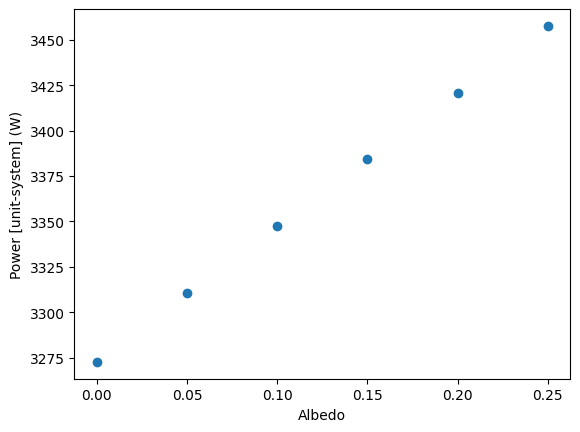

In [4]:
# select the day of year to plot
day_of_year = 250

# select the Hour of day to plot
hour_of_day = 12

# select the parameter to plot
parameter = 'Power [unit-system] (W)'

# create a list to collect the parameter values
parameter_list = []

# for each df in the df_list, extract the row with the selected day_of_year and hour_of_day
for df in df_list:
    # extract the row with the selected day_of_year and hour_of_day
    df = df[(df['Day of year'] == day_of_year) & (df['Hour'] == hour_of_day)]
    # extract the parameter from the row
    parameter_value = df[parameter].values[0]
    # append the parameter_value to the parameter_list
    parameter_list.append(parameter_value)

# plot the parameter_list against the albedo_list
plt.scatter(albedo_list, parameter_list)
plt.xlabel('Albedo')
plt.ylabel(parameter)
plt.show()
